In [1]:
"""
Plotting figure 4 in the paper (synergy).
"""

'\nPlotting figure 4 in the paper (synergy).\n'

In [2]:
import sys
import os

# setting directories
ROOT_DIR = os.getcwd()
if os.path.basename(ROOT_DIR) == "notebooks":
    ROOT_DIR = os.path.dirname(ROOT_DIR)

SRC_DIR = os.path.join(ROOT_DIR, "src")
DATA_DIR = os.path.join(ROOT_DIR, "data")

sys.path.append(SRC_DIR)

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import ttest_ind
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [4]:
from matplotlib.ticker import LogLocator
from matplotlib.colors import ListedColormap
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

In [5]:
# make jupyter notebook plotting looks clearer
# doesn't change the figure size nor display size
%config InlineBackend.figure_format = 'retina'

In [6]:
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'serif'

In [7]:
import matplotlib.lines as mlines

def add_vertical_bracket(fig, ax_top, ax_bottom, text,
                         x_offset=0.015, arm=0.012,
                         text_offset=0.008, lw=1.5, fontsize=12):
    """
    Draw a vertical significance bracket to the right of two stacked axes.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
    ax_top, ax_bottom : matplotlib axes
        The upper and lower axes to connect.
    text : str
        Text to display, e.g. r'$p < 10^{-5}$'
    x_offset : float
        How far to the right of the axes to place the bracket (figure coords).
    arm : float
        Horizontal arm length of the bracket (figure coords).
    text_offset : float
        Distance between bracket and text (figure coords).
    """
    bbox_top = ax_top.get_position()
    bbox_bottom = ax_bottom.get_position()

    # right side x position
    x = max(bbox_top.x1, bbox_bottom.x1) + x_offset

    # vertical span
    y_top = bbox_top.y0 + bbox_top.height * 0.4
    y_bottom = bbox_bottom.y0 + bbox_bottom.height * 0.6

    # vertical line
    fig.add_artist(mlines.Line2D(
        [x, x], [y_bottom, y_top],
        transform=fig.transFigure, color='black', lw=lw
    ))

    # top arm
    fig.add_artist(mlines.Line2D(
        [x - arm, x], [y_top, y_top],
        transform=fig.transFigure, color='black', lw=lw
    ))

    # bottom arm
    fig.add_artist(mlines.Line2D(
        [x - arm, x], [y_bottom, y_bottom],
        transform=fig.transFigure, color='black', lw=lw
    ))

    # text
    fig.text(
        x + text_offset, (y_top + y_bottom) / 2,
        text, rotation=90, va='center', ha='left', fontsize=fontsize
    )

results for t test between group 1 and 4 -3.9458980413301696 8.219050065130603e-05
results for t test between group 4 and 20 -2.3762557768191543 0.01758903974095216
0.00025361567208169824 0.048943485798216765 0.24924895487940602


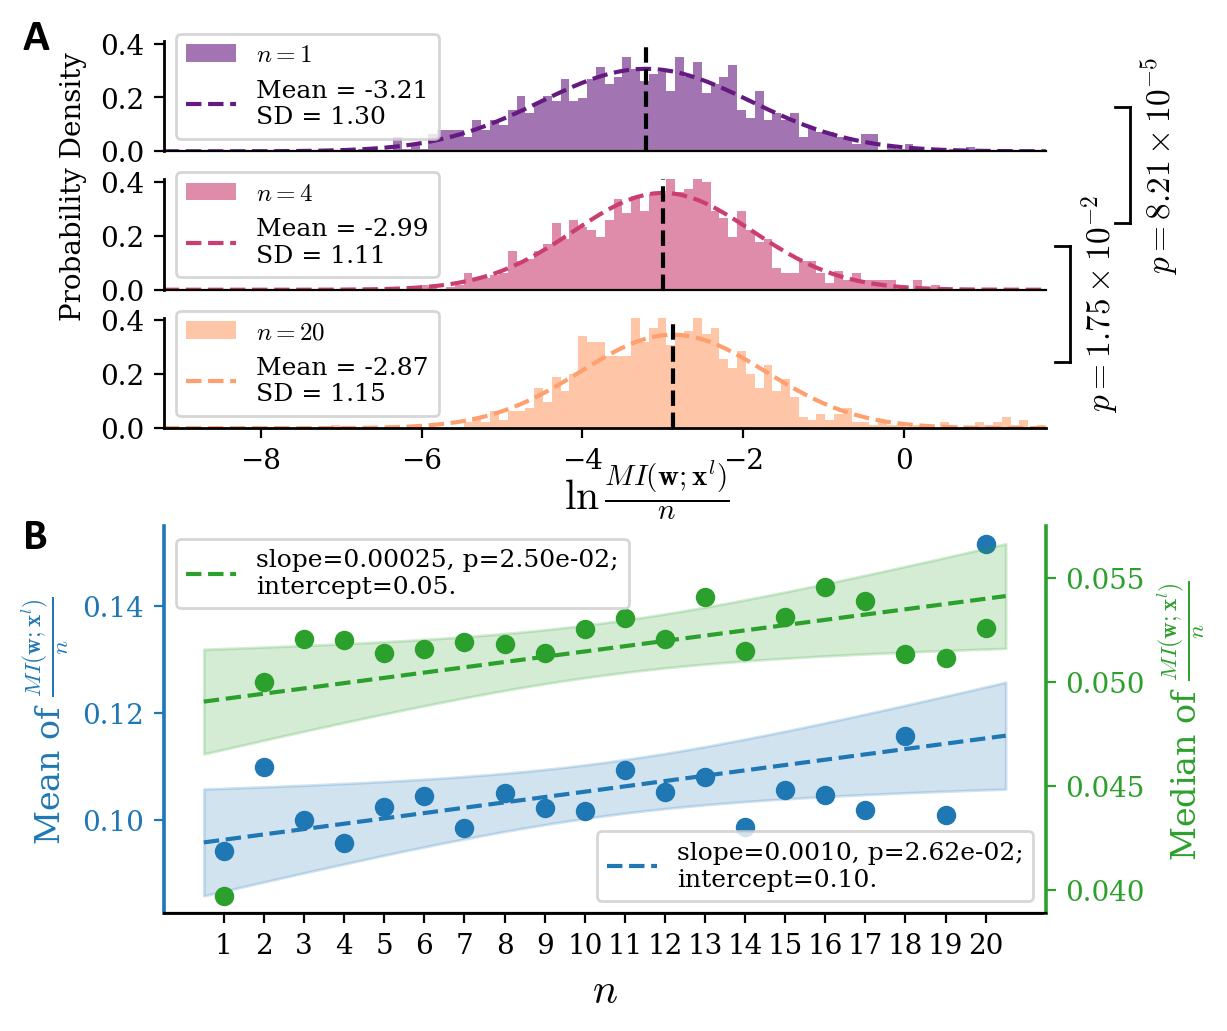

In [8]:
# Set up the plotting area
fig = plt.figure(figsize=(6, 5))

# three panels
gs = fig.add_gridspec(2, 1)


#-------------------------- panel A ---------------------------------------------------

gsA = gs[0].subgridspec(3, 1)

axA1 = fig.add_subplot(gsA[0])
axA2 = fig.add_subplot(gsA[1])
axA3 = fig.add_subplot(gsA[2])

axes = [axA1, axA2, axA3]

# Load the data from the CSV file
df = pd.read_csv(os.path.join(DATA_DIR, "generated_samples_20k_covdifferent_eigenmethod.csv"))

# Get the unique values of 'n'
unique_n_values = [1, 4, 20]


# Define a color map
colors = plt.cm.magma(np.linspace(0.3, 0.8, len(unique_n_values))) #plt.get_cmap('tab10', len(unique_n_values))

# Set common xlim and ylim for all subplots
common_xlim = [np.min(np.log(df['MI'] / df['n'])), np.max(np.log(df['MI']/ df['n'])) + 0.1]
common_ylim = [-1e-4, 0.41]  # Assuming a reasonable log scale range; adjust as necessary

for ax in axes:
    ax.set_xlim(common_xlim)
    ax.set_ylim(common_ylim)

# list for preparing t test
data_ttest = []

# Plot histograms for MI/n for each unique 'n' value
for i, n_value in enumerate(unique_n_values):
    # Filter the DataFrame for the current 'n' value
    subset = df[df['n'] == n_value]

    # Calculate MI / n
    mi_over_n = subset['MI'] / subset['n']

    # take the log MI
    logmi_over_n = np.log(mi_over_n)

    # append for ttest
    data_ttest.append(logmi_over_n)

    # Plot the histogram on the corresponding subplot
    axes[i].hist(logmi_over_n, bins=100, range=common_xlim, alpha=0.6, color=colors[i], label=f'$n={n_value}$', density=True, log=False)  ########

    # Fit a normal distribution to the data
    mu, std = norm.fit(logmi_over_n)

    # Plot the PDF of the fitted normal distribution
    xmin, xmax = common_xlim[0], common_xlim[1]
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    axes[i].plot(x, p, color=colors[i], linewidth=1.5, ls='--', label="Mean = %.2f\nSD = %.2f" % (mu, std))

    # Add a vertical line at the mean (center) of the distribution
    axes[i].axvline(mu, color='k', linestyle='dashed', linewidth=1.5)

    # y ticks
    axes[i].set_yticks([0.0, 0.2, 0.4])

    # Add legends
    axes[i].legend(fontsize=9)

    # Customize the axes
    axes[i].spines['top'].set_visible(False)    # Remove top axis
    axes[i].spines['right'].set_visible(False)  # Remove right axis
    
    # Make left and bottom axes bolder
    axes[i].spines['left'].set_linewidth(1)
    ax.spines['bottom'].set_linewidth(1)

    # Disable x-ticks and x-tick labels for all but the bottom subplot
    if i < len(unique_n_values) - 1:
        axes[i].set_xticks([])
        axes[i].set_xticklabels([])
    

# do t - test between them
for i in range(len(unique_n_values) - 1):
    t_stat, p_value = ttest_ind(data_ttest[i], data_ttest[i+1])
    print(f"results for t test between group {unique_n_values[i]} and {unique_n_values[i+1]}", t_stat, p_value)

# Set a common title, xlabel, and ylabel for the entire figure
axA3.text(-3.2, -0.3, r'$\ln \frac{MI(\mathbf{w};\mathbf{x}^l)}{n}$', ha='center', fontsize=15)  # X-axis label
axA3.text(-10.5, 0.9, 'Probability Density', va='center', rotation='vertical', fontsize=10)  # Y-axis label

# add panel letter
axA1.text(
        -0.16, 3.7, 'A',
        transform=ax.transAxes,
        fontsize=16,
        fontname='Calibri',
        fontweight='bold',
        va='top',
        ha='left'
    )


# -------------------- panel B -----------------------------------------------------------------
axB= fig.add_subplot(gs[1])
ax = axB

# Get the unique values of 'n'
unique_n_values = sorted(df['n'].unique()) 

# data for scatter
x = []
y = []

# for plot
x1 = []
y1 = []
y2 = []

#
data = []

# Read MI/n for each unique 'n' value
for i, n_value in enumerate(unique_n_values):
    # Filter the DataFrame for the current 'n' value
    subset = df[df['n'] == n_value]

    # Calculate MI / n
    mi_over_n = np.array(subset['MI'] / subset['n'])

    # append to data
    #x.extend([i+1] * len(logmi_over_n))
    #y.extend(logmi_over_n)
    x1.extend([i+1])
    y1.extend([np.mean(mi_over_n)]) 
    y2.extend([np.median(mi_over_n)])  
    #data.append(logmi_over_n)


ax1 = ax

colors = ['#1f77b4', '#2ca02c']

# scatter plot
ax1.scatter(x1, y1, color=colors[0])  # Green scatter plot
ax1.set_xlabel('$n$', fontsize=15)
ax1.set_xticks(range(1, 20 + 1))
ax1.set_ylabel(r'Mean of $\frac{MI(\mathbf{w};\mathbf{x}^l)}{n}$', color=colors[0], fontsize=12)

# Pearson correlation coefficient on log-log scale
corr, p_value = pearsonr(x1, y1)

# Linear regression
X = np.array(x1).reshape(-1, 1)
Y = np.array(y1).reshape(-1, 1)

# Linear regression using statsmodels
X = sm.add_constant(X)   # adds intercept term
Y = Y
model = sm.OLS(Y, X).fit()

# Extract regression results
intercept = model.params[0]
slope = model.params[1]
R2 = model.rsquared

# 95% CI for intercept and slope
conf_int = model.conf_int(alpha=0.05)

# Plot the regression line
X_pred = np.linspace(np.min(X) - 0.5, np.max(X) + 0.5, 100).reshape(-1, 1)
X_pred_with_const = sm.add_constant(X_pred)
Y_pred = model.predict(X_pred_with_const)
ax1.plot(X_pred, Y_pred, color=colors[0], linewidth=1.5, linestyle='--',
        label=f'slope={slope:.4f}, p={p_value:.2e};\nintercept={intercept:.2f}.')

# fill the ci prediction shadow
pred = model.get_prediction(X_pred_with_const)
pred_ci = pred.conf_int()

ax1.fill_between(
    X_pred[:,0],
    pred_ci[:,0],
    pred_ci[:,1],
    color=colors[0],
    alpha=0.2
)

# Customize the axes
ax1.spines['top'].set_visible(False)    # Remove top axis
ax1.spines['right'].set_visible(False)

ax1.spines['left'].set_color(colors[0])
ax1.tick_params(axis='y', colors=colors[0])
ax1.yaxis.label.set_color(colors[0])

# Make left and bottom axes bolder
ax1.spines['left'].set_linewidth(1.3)
ax1.spines['bottom'].set_linewidth(1)




# Create the second scatter plot (y2) with the right y-axis
# the std
ax2 = ax1.twinx()
ax2.scatter(x1, y2, color=colors[1])  # Blue scatter plot
ax2.set_ylabel(r'Median of $\frac{MI(\mathbf{w};\mathbf{x}^l)}{n}$', color=colors[1], fontsize=12)
ax2.tick_params(axis='y', labelcolor=colors[1])

# Pearson correlation coefficient on log-log scale
corr, p_value = pearsonr(x1, y2)

# Linear regression
X = np.array(x1).reshape(-1, 1)
Y = np.array(y2).reshape(-1, 1)


# Linear regression using statsmodels
X = sm.add_constant(X)   # adds intercept term
Y = Y
model = sm.OLS(Y, X).fit()

# Extract regression results
intercept = model.params[0]
slope = model.params[1]
R2 = model.rsquared

# 95% CI for intercept and slope
conf_int = model.conf_int(alpha=0.05)

print(slope, intercept, R2)

# Plot the regression line
X_pred = np.linspace(np.min(X) - 0.5, np.max(X) + 0.5, 100).reshape(-1, 1)
X_pred_with_const = sm.add_constant(X_pred)
Y_pred = model.predict(X_pred_with_const)
ax2.plot(X_pred, Y_pred, color=colors[1], linewidth=1.5, linestyle='--',
        label=f'slope={slope:.5f}, p={p_value:.2e};\nintercept={intercept:.2f}.')  


# fill the ci prediction shadow
pred = model.get_prediction(X_pred_with_const)
pred_ci = pred.conf_int()

ax2.fill_between(
    X_pred[:,0],
    pred_ci[:,0],
    pred_ci[:,1],
    color=colors[1],
    alpha=0.2
)

# Customize the axes
ax2.spines['top'].set_visible(False)    # Remove top axis
ax2.spines['left'].set_visible(False)

ax2.spines['right'].set_color(colors[1])
ax2.tick_params(axis='y', colors=colors[1])
ax2.yaxis.label.set_color(colors[1])

# Make left and bottom axes bolder
ax2.spines['right'].set_linewidth(1.3)



# Add legends
ax1.legend(loc="lower right", fontsize=9)
ax2.legend(loc="upper left", fontsize=9)

# add panel letter
ax2.text(
        -0.16, 1.02, 'B',
        transform=ax.transAxes,
        fontsize=16,
        fontname='Calibri',
        fontweight='bold',
        va='top',
        ha='left'
    )

# --------------overall editing-------------------------------------
plt.tight_layout(pad=0.0, w_pad=0.00, h_pad=-0.0)

# p-value differences across histograms for panel A
add_vertical_bracket(fig, axA1, axA2, r'$p = 8.21 \times 10^{-5}$', x_offset=0.07, arm=0.012, lw=1)
add_vertical_bracket(fig, axA2, axA3, r'$p = 1.75 \times 10^{-2}$', x_offset=0.02, lw=1) 

#plt.tight_layout()
plt.show()
#plt.savefig("fig_4.pdf", bbox_inches="tight")